In [1]:
import numpy as np
import matplotlib.pyplot as plt
from codes.Quantum import *
from codes.CSPSA import *

In [9]:
Psi_ab = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
# Psi_ab = np.array([ 1, 0, 0, 1 ])/np.sqrt(2)
Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten() 
Rho = np.outer( Psi, Psi.conj() )
Rho[:8,:8]

array([[ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.125]])

$ Z \rightarrow U = Z(Z^\dagger Z)^{-1/2} $

$U^\dagger U = (Z^\dagger Z)^{-1/2} Z^\dagger Z(Z^\dagger Z)^{-1/2} =  (Z^\dagger Z)^{-1} Z^\dagger Z$ = I

In [3]:
from scipy.linalg import sqrtm 
from scipy.linalg import inv 

In [4]:
def complex2unitary( Z ):

    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )

    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

In [5]:
def obj_fun( Z ):

    Z  = np.array(Z)

    Z = complex2unitary( Z )

    Measures = triple_kron( Z[0], Z[1], Z[2] )
    probs    = np.sum( Measures.conj() * ( Rho @ Measures ), 
                        axis=0 ).reshape(6*[2]) 

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    
    return inequality

In [6]:
Z = random_unitary(4,3)
obj_fun( Z )

(-0.2953431050887222-1.4950224573506056e-18j)

In [7]:
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)


Our objective function delivers the maximum violation of the non-local Wagon-Wheel inequality

In [8]:
obj_fun( [vec_alice, vec_bob, vec_charlie] ), (np.sqrt(2)-1)/16 

(0.025888347648318454, 0.025888347648318447)

Optimization with CSPSA

In [50]:
gains = [ 3, 0, 0.1, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False )
max_iter = 1000

Random initial condition

In [51]:
inequality1 = []

for _ in range(1):
    Z_in = random_unitary(4,3)

    results1 = cspsa.minimize( obj_fun, 
                            Z_in, 
                            max_iter, 
                            postprocessing=complex2unitary )
    inequality1.append( results1.fun )

Text(0.5, 1.0, 'Optimization of $\\Delta$-inequality with random initial condition')

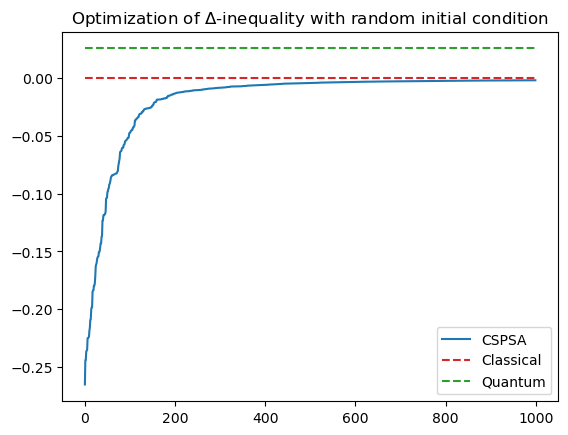

In [52]:
inequality1_mean = np.mean(inequality1, axis=0)

plt.plot( inequality1_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines((np.sqrt(2)-1)/16 ,0, max_iter, colors='tab:green', linestyles='--')
plt.legend(['CSPSA', 'Classical', 'Quantum' ], loc='lower right')
plt.title('Optimization of $\Delta$-inequality with random initial condition')

Initial condition near to the optimum 

In [53]:
inequality2 = []

for _ in range(1):
        Z_in2 = np.array([vec_alice,vec_bob,vec_charlie]) \
                + 0.2 * random_unitary(4,3)

        results2 = cspsa.minimize( obj_fun, 
                                Z_in2, 
                                max_iter, 
                                postprocessing=complex2unitary )
        inequality2.append( results2.fun )

Text(0.5, 1.0, 'Optimization of $\\Delta$-inequality with near optimal initial condition')

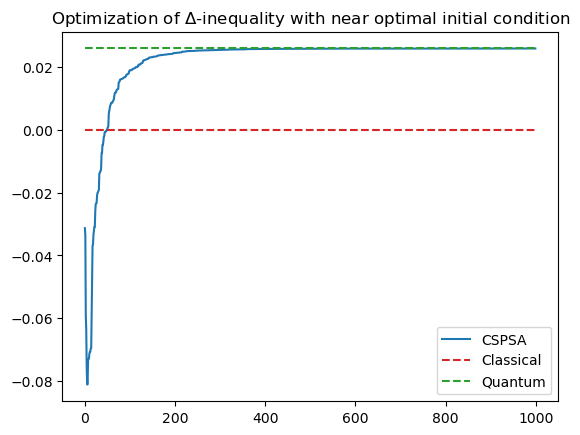

In [54]:
inequality2_mean = np.mean(inequality2, axis=0)

plt.plot( inequality2_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines((np.sqrt(2)-1)/16 ,0, max_iter, colors='tab:green', linestyles='--')
plt.legend(['CSPSA', 'Classical', 'Quantum' ], loc='lower right' )
plt.title('Optimization of $\Delta$-inequality with near optimal initial condition')

Initial condition $I\otimes U_{\rm random}$

In [55]:
inequality3 = []
for _ in range(1):
    Z_in3 = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ]) \
            
    results3 = cspsa.minimize( obj_fun, 
                                Z_in3, 
                                max_iter, 
                                postprocessing=complex2unitary ) 
    
    inequality3.append( results3.fun )

Text(0.5, 1.0, 'Optimization of $\\Delta$-inequality with local random initial condition')

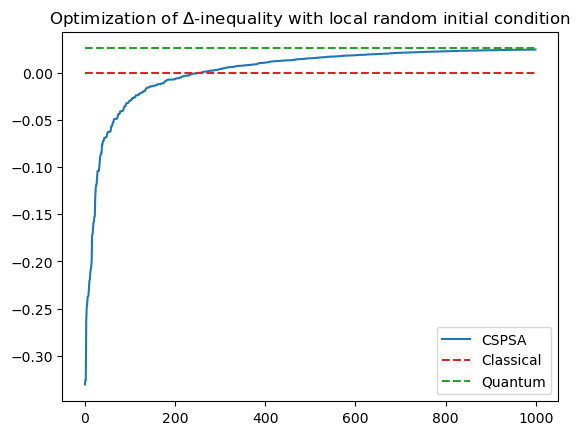

In [56]:
inequality3_mean = np.mean(inequality3, axis=0)

plt.plot( inequality3_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines((np.sqrt(2)-1)/16 ,0, max_iter, colors='tab:green', linestyles='--')
plt.legend(['CSPSA', 'Classical', 'Quantum' ], loc='lower right' )
plt.title('Optimization of $\Delta$-inequality with local random initial condition')


Text(0.5, 1.0, 'Optimization of $\\Delta$-inequality')

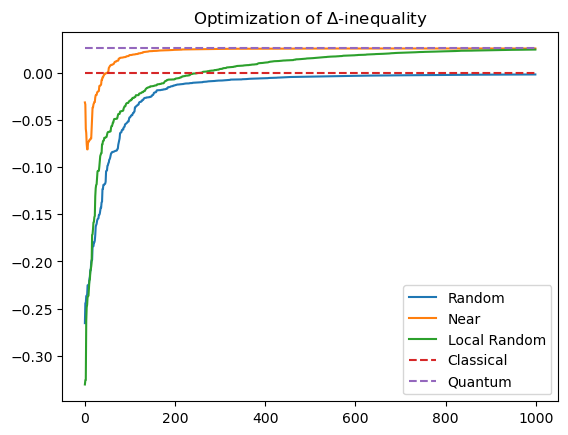

In [57]:
plt.plot( inequality1_mean )
plt.plot( inequality2_mean )
plt.plot( inequality3_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines((np.sqrt(2)-1)/16 ,0, max_iter, colors='tab:purple', linestyles='--')
plt.legend(['Random','Near','Local Random', 'Classical', 'Quantum' ], loc='lower right' )
plt.title('Optimization of $\Delta$-inequality')
